# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the Rubin/LSST 10-year baseline cadence using `lightcurvelynx`.

**Survey**: LSST baseline v5.3.0 OpSim (`baseline_v5.3.0_10yrs.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

No need to set `LIGHTCURVELYNX_DATA_DIR` — the default cache at `~/.cache/lightcurvelynx` is used.  
The OpSim v5.3.0 database is already downloaded there.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
from lightcurvelynx import _LIGHTCURVELYNX_DOWNLOAD_DATA_DIR
print(f"Data dir: {_LIGHTCURVELYNX_DOWNLOAD_DATA_DIR}")

Data dir: /Users/mi/.cache/lightcurvelynx


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.astro_utils.dustmap import SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 1.0,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean":  -0.054,  "c_sigma_minus":  0.043, "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # placeholder; overwritten from opsim
}

## 3. Load LSST OpSim

The file is downloaded once and cached locally by `OpSim.from_url()`.

In [21]:
# opsim_url = "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs5.0/baseline/baseline_v5.0.1_10yrs.db"
# opsim = OpSim.from_url(
#     opsim_url,
# )
opsim_path = _LIGHTCURVELYNX_DOWNLOAD_DATA_DIR / "opsim" / "baseline_v5.0.1_10yrs.db"
opsim = OpSim.from_db(
    opsim_path,
    # sql_query="SELECT * FROM observations WHERE scheduler_note NOT LIKE 'DD:%'",
    sql_query="SELECT * FROM observations WHERE target_name NOT LIKE '%DDF%' AND target_name LIKE '%lowdust%'",
)

print(f"OpSim loaded: {len(opsim):,} observations")
print(f"MJD range: {opsim['time'].min():.1f} – {opsim['time'].max():.1f}")
print(f"Filters:    {sorted(opsim['filter'].unique())}")

OpSim loaded: 1,607,827 observations
MJD range: 60981.0 – 64632.3
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [23]:
sky_coverage = opsim.estimate_coverage()    
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 19835 deg²


In [28]:
import pandas as pd
pd.set_option('display.max_rows', None)
opsim['target_name'].value_counts()
# pd.reset_option('display.max_rows')

target_name
lowdust                                     1446119
lowdust, dusty_plane                          39977
lowdust, nes                                  26571
lowdust, bulgy                                12373
lowdust, LMC_SMC                               7095
lowdust, GW_case_D_E_i1                        6145
lowdust, scp                                   5630
GW_case_B_C_i0, lowdust                        5100
lowdust, GW_case_D_E_i2                        5010
lowdust, GW_case_D_E_i3                        4445
GW_case_B_C_i4, lowdust                        4435
lowdust, GW_case_B_C_i1                        4390
lowdust, GW_case_B_C_i5                        4380
lowdust, GW_case_B_C_i2                        4024
lowdust, GW_case_B_C_i3                        3809
lowdust, virgo                                 2760
lowdust, euclid_overlap                        2638
lowdust, LensedBNS_B_i0                        2621
lowdust, GW_case_D_E_i0                        2164


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = float(opsim["time"].min())
t_max = float(opsim["time"].max())
SIM_PARAMS["tmin"] = t_min
SIM_PARAMS["tmax"] = t_max

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
print(f"Expected SNe Ia = {nsn:,}")

nsn = int(nsn * 0.002)
print(f"Expected SNe Ia (0.2%) = {nsn:,}")

Survey length = 10.00 years
Solid angle   = 8.5710 sr  (28,137 deg²)
Expected SNe Ia = 32,997,873
Expected SNe Ia (0.2%) = 65,995


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

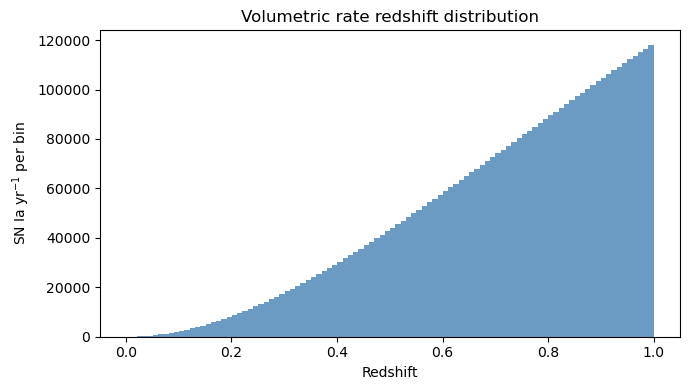

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — AsymmetricGaussian($\mu=0.973$, $\sigma_-=1.472$, $\sigma_+=0.222$)
- **c** — AsymmetricGaussian($\mu=-0.054$, $\sigma_-=0.043$, $\sigma_+=0.101$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.1$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [10]:
# RA/Dec: uniform over the opsim footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(opsim, node_label="radec")
moc = opsim.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Asymmetric Gaussian SALT3 parameter priors
def asymmetric_gaussian_pdf(x, mu, sigma_minus, sigma_plus):
    norm_factor = np.sqrt(2 / np.pi) / (sigma_minus + sigma_plus)
    return np.where(
        x < mu,
        norm_factor * np.exp(-0.5 * ((x - mu) / sigma_minus) ** 2),
        norm_factor * np.exp(-0.5 * ((x - mu) / sigma_plus) ** 2),
    )
def x1_pdf(x):
    return asymmetric_gaussian_pdf(x, SIM_PARAMS["x1_mean"], SIM_PARAMS["x1_sigma_minus"], SIM_PARAMS["x1_sigma_plus"])
def c_pdf(c):
    return asymmetric_gaussian_pdf(c, SIM_PARAMS["c_mean"], SIM_PARAMS["c_sigma_minus"], SIM_PARAMS["c_sigma_plus"])

x1_func = SamplePDF(x1_pdf, node_label="x1")
c_func = SamplePDF(c_pdf, node_label="c")
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),  
)

mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)
# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [11]:
opsim.columns

Index(['observationId', 'ra', 'dec', 'time', 'flush_by_mjd', 'exptime', 'band',
       'filter', 'rotation', 'rotSkyPos_desired', 'nexposure', 'airmass',
       'seeingFwhm500', 'seeing', 'seeingFwhmGeom', 'skybrightness', 'night',
       'slewTime', 'visitTime', 'slewDistance', 'maglim', 'altitude',
       'azimuth', 'paraAngle', 'pseudoParaAngle', 'cloud', 'moonAlt', 'sunAlt',
       'scheduler_note', 'target_name', 'target_id', 'observationStartLST',
       'rotTelPos', 'rotTelPos_backup', 'moonAz', 'sunAz', 'sunRA', 'sunDec',
       'moonRA', 'moonDec', 'moonDistance', 'solarElong', 'moonPhase',
       'cummTelAz', 'observation_reason', 'science_program',
       'cloud_extinction', 'zp', 'psf_footprint', 'sky_bg_e'],
      dtype='object')

In [12]:
param_cols = [
    "source.t0",
    "source.x0",
    "source.x1",
    "source.c",
    "source.redshift",
    "source.ra",
    "source.dec",
    "x0_func.distmod",
]
obstable_save_cols = ["zp"]

parallel_executor = "loky"  # Options: "loky", "dask", None
if parallel_executor == "loky":
    try:
        import loky
        executor = loky.get_reusable_executor(max_workers=4)
        results = simulate_lightcurves(
            model=source,
            num_samples=nsn,
            survey_info=opsim,
            passbands=passbands,
            param_cols=param_cols,
            obstable_save_cols=obstable_save_cols,
            rng=RNG,
            num_jobs=4,
            batch_size=2000,
            executor=executor,
        )
    except ImportError:
        print("Loky is not installed")
elif parallel_executor == "dask":
    try:
        import dask.distributed

        with dask.distributed.Client() as client:
            print(f"Dask dashboard link: {client.dashboard_link}")
            results = simulate_lightcurves(
                model=source,
                num_samples=nsn,
                survey_info=opsim,
                passbands=passbands,
                param_cols=param_cols,
                obstable_save_cols=obstable_save_cols,
                rng=RNG,
                num_jobs=4,
                batch_size=2000,
                executor=client,
            )
    except ImportError:
        print("Dask is not installed")
else:
    executor = None
    results = simulate_lightcurves(
        model=source,
        num_samples=nsn,
        survey_info=opsim,
        passbands=passbands,
        param_cols=param_cols,
        obstable_save_cols=obstable_save_cols,
        rng=RNG,
        num_jobs=4,
        batch_size=2000,
        executor=executor,
    )
print(f"Generated {len(results)} light curves")
print(results["lightcurve"][0])

print(f"Simulated {len(results):,} SNe Ia")
results.head()

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:681: FutureWarning: The passbands argument is deprecated and will be removed from future versions.
  warnings.warn(
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:693: FutureWarning: Passing ObsTable objects directly in survey_info is deprecated and will be removed in future versions. Please use SurveyInfo objects instead.
  warnings.warn(
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Simulating:  66%|██████▌   | 1320/2000 [00:11<00:06, 113.05obj/s]/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by 

Generated 65995 light curves
              mjd filter        flux     fluxerr  flux_perfect  survey_idx  \
0    60981.298506      r  -32.083970  119.051251      0.000000           0   
1    60993.344409      i   77.588739  228.190154      0.000000           0   
..            ...    ...         ...         ...           ...         ...   
821  64612.377319      z -265.823679  421.951237      7.273961           0   
822  64629.337357      i -111.578459  177.796506      6.012728           0   

     obs_idx  is_saturated        zp  
0        593         False  0.553591  
1       3149         False  0.658613  
..       ...           ...       ...  
821  1942016         False  0.938847  
822  1947408         False  0.656807  

[823 rows x 9 columns]
Simulated 65,995 SNe Ia


id          ra        dec  nobs            t0         z     source_t0  \
0   0   86.030016 -55.103314   823  64241.514289  0.786656  64241.514289   
1   1  125.521946  -8.372465   862  63631.046518  0.704254  63631.046518   
2   2  321.638370  -6.967320   851  64501.879460  0.818871  64501.879460   
3   3  203.405816 -23.720353   827  63350.326982  0.758579  63350.326982   
4   4  275.252869  -1.191353   266  62543.901831  0.735305  62543.901831   

   source_x0  source_x1  source_c  source_redshift   source_ra  source_dec  \
0   0.000005   0.281792 -0.004790         0.786656   86.030016  -55.103314   
1   0.000004  -0.405393  0.032726         0.704254  125.521946   -8.372465   
2   0.000004   0.824700  0.033708         0.818871  321.638370   -6.967320   
3   0.000006   0.925328 -0.059303         0.758579  203.405816  -23.720353   
4   0.000004   0.458174  0.058432         0.735305  275.252869   -1.191353   

   x0_func_distmod                                         lightcurve  \
0        43.441534  [{mjd: 60981.298506, filter: 'r', flux: -32.08...   
1        43.148158  [{mjd: 61002.35597, filter: 'i', flux: 35.5455...   
2        43.548239  [{mjd: 61125.399605, filter: 'z', flux: 1001.5...   
3        43.345037  [{mjd: 61100.380497, filter: 'y', flux: -42.61...   
4        43.262403  [{mjd: 61159.325745, filter: 'y', flux: -569.6...   

                                              params  
0  {'radec.ra': 86.0300163355615, 'radec.dec': -5...  
1  {'radec.ra': 125.5219461489469, 'radec.dec': -...  
2  {'radec.ra': 321.63836957886815, 'radec.dec': ...  
3  {'radec.ra': 203.40581584721804, 'radec.dec': ...  
4  {'radec.ra': 275.2528694830835, 'radec.dec': -...

## 9. Apply Selection Cuts

Apply detection, saturation, and quality cuts to the simulated light curves.

In [13]:
# Drop light curves with no observations
lightcurves = results.dropna(subset=['lightcurve'])

# Compute SNR and detection flag
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux'] / lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.0
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# Drop saturated observations
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated == False").dropna(subset=['lightcurve'])

# Apply detection cut
print("Before detection cut: nsn =", len(lightcurves))
lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After detection cut:  nsn =", len(lightcurves_after_detection))

# Quality cuts: >=7 unique phases in [-10, 40] days, >=2 pre-peak, >=3 post-peak, >=2 bands
def lc_quality_cuts(flux, mjd, filter, z, t0,
                    n_phases=10, n_before_peak=2, n_after_peak=3, n_bands=2):
    phases = np.floor((mjd - t0) / (1.0 + z))
    unique_phases, unique_idx = np.unique(phases, return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases <= 40)
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_cut &= np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

pass_quality_cut = lightcurves_after_detection.reduce(
    lc_quality_cuts,
    "lightcurve.flux", "lightcurve.mjd", "lightcurve.filter", "z", "t0",
)
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts:   nsn =", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx, "pass_quality_cuts"] = True

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/c

Before detection cut: nsn = 65983


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1352: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After detection cut:  nsn = 21432


/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_54651/2235164451.py:31: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_quality_cut = lightcurves_after_detection.reduce(


After quality cuts:   nsn = 1551


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:334: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


## 10. Diagnostics

Quick sanity checks on the simulated population.

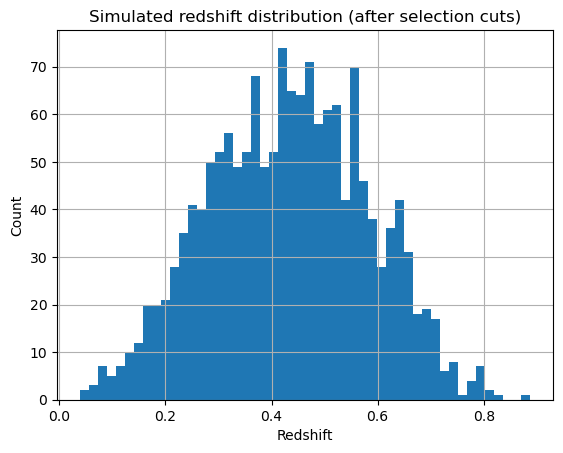

In [14]:
# redshift distribution of simulated SNe (post-cuts)
fig, ax = plt.subplots()
lightcurves_after_quality_cut["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution (after selection cuts)")
plt.show()

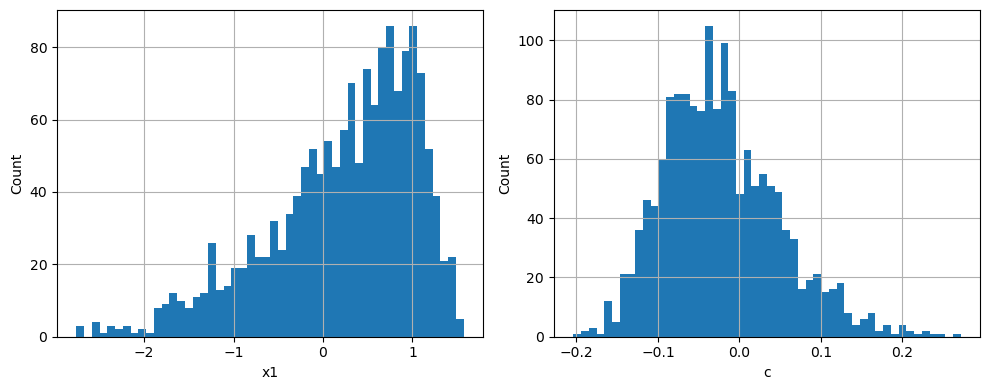

In [15]:
# x1 and c distributions (post-cuts)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
lightcurves_after_quality_cut["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
lightcurves_after_quality_cut["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

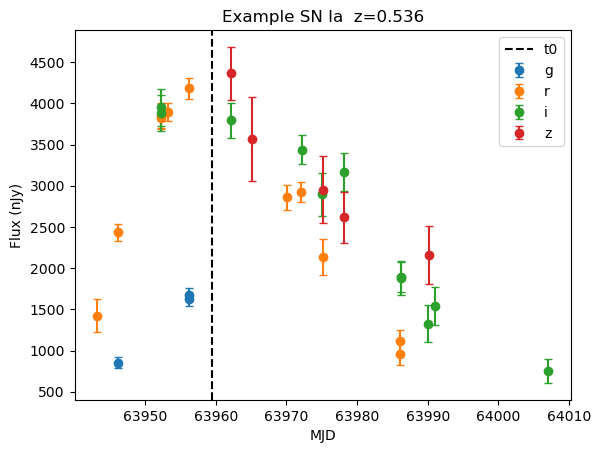

In [16]:
# example light curve for a single SN (post-cuts)
sn = lightcurves_after_quality_cut.iloc[np.random.choice(len(lightcurves_after_quality_cut))]
lc = sn["lightcurve"]
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"]) / (1.0 + sn["source_redshift"]) > -20
    mask &= (lc["mjd"] - sn["source_t0"]) / (1.0 + sn["source_redshift"]) < 100
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

## 11. Save Results

In [17]:
# output_dir = Path("output")
# output_dir.mkdir(exist_ok=True)

# # results.to_parquet(output_dir / "lsst_snia_v530_results.parquet")
# # print(f"Saved all simulated SNe to {output_dir / 'lsst_snia_v530_results.parquet'}")

# lightcurves_after_quality_cut.to_parquet(output_dir / "lsst_snia_v501_after_cuts.parquet")
# print(f"Saved post-cut SNe to {output_dir / 'lsst_snia_v501_after_cuts.parquet'}")